# Hotel Room-Nights Forecasting Pipeline

**Enjoy Costa Rica — Revenue Analytics**

Pronóstico de **room nights** (noches de habitación vendidas, `rooms_sold`) — la variable de demanda estructural del portafolio. Decisión de gerencia: demanda primero; monetario después (`revenue ≈ room nights × ADR`).

## Estructura del Notebook

| Sección | Descripción |
|---------|-------------|
| 0 | Setup & Configuración |
| 1 | Carga de Datos (validación de target + reporte de filas financieras NULL) |
| 2 | Análisis Exploratorio (EDA de room nights + chequeo de violaciones de capacidad) |
| 3 | Preprocesamiento & Feature Engineering (agregación NULL-safe, sin fuga de datos) |
| 4 | Modelos Estadísticos (Prophet, SARIMAX, ETS) — multi-paso alineado por fecha |
| 5 | Modelos de ML (LightGBM, XGBoost, CatBoost) — protocolo honesto recursivo |
| 6 | Deep Learning (PatchTST; TimesFM excluido honestamente en Windows) |
| 7 | Comparación Final (incluye baseline Seasonal Naive; DM con Newey-West) |
| 8 | Pronóstico Futuro (90 días, techo de capacidad, ocupación implícita) |
| 9 | Conclusiones & Advertencias Honestas |

> **Protocolo de evaluación**: todas las métricas del test son **multi-paso reales**
> (los modelos nunca ven los reales del test como entradas), en **room nights**,
> sobre la **misma serie** (portafolio agregado diario), con baseline de referencia.
>
> ⚠️ **DATOS SINTÉTICOS**: este notebook usa `hotel_roomnights_sample.csv`, un
> archivo ficticio generado con identidades físicas exactas. Las cifras validan
> la metodología; conecte el SQL real para números de negocio.

---
## Section 0: Setup & Imports

**Buenas prácticas aplicadas:**
- **Reproducibilidad**: semilla global (`SEED=42`) y configuración centralizada en `config.yaml`.
- **Separación de responsabilidades**: la lógica vive en `src/forecasting/` (43 tests); el notebook orquesta, visualiza y documenta.
- **Trazabilidad**: logging estructurado de cada componente.

In [1]:
import sys
import warnings
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Add src to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# Load config
CONFIG_PATH = PROJECT_ROOT / 'config.yaml'
with open(CONFIG_PATH) as f:
    CONFIG = yaml.safe_load(f)

RN = CONFIG['roomnights']
TARGET_COL = RN['target_col']            # rooms_sold
AVAIL_COL = RN['available_rooms_col']    # available_rooms

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")
print(f"Target: {TARGET_COL} (room nights) | Capacity col: {AVAIL_COL}")

Project root: C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
NumPy: 1.26.4, Pandas: 2.2.3
Target: rooms_sold (room nights) | Capacity col: available_rooms


In [2]:
# Import forecasting modules
from src.forecasting.data import (
    DataLoader, aggregate_daily_target, apply_capacity_ceiling, implied_occupancy,
)
from src.forecasting.eda import EDAAnalyzer, EDAVisualizer
from src.forecasting.preprocessing import PreprocessingPipeline
from src.forecasting.models.statistical import ProphetForecaster, SARIMAXForecaster, ETSForecaster
from src.forecasting.models.ml import LightGBMForecaster, XGBoostForecaster, CatBoostForecaster
from src.forecasting.models.dl import TimesFMForecaster, PatchTSTForecaster
from src.forecasting.evaluation import Evaluator, EvaluationVisualizer
from src.forecasting.forecasting.recursive import recursive_forecast

print("All modules imported successfully!")

All modules imported successfully!


---
## Section 1: Data Loading

**Módulo `data/` — `DataLoader` + validación de esquema por target**

| Práctica | Justificación |
|---|---|
| Validación de `rooms_sold` como target requerido | *Fail fast*: un dato sin la columna objetivo se detecta aquí |
| Reporte de filas financieras (NULL operacional) | Las filas de `enjoy_fac_hotel_financial` traen `rooms_sold` NULL; deben excluirse de la serie objetivo |
| Generador sintético determinista | Archivo ficticio con identidades físicas exactas para desarrollo offline |

In [3]:
# Load room-nights data (synthetic sample file for offline development).
# To use SQL: DataLoader(db_config={...}, csv_path=None).load(target_col=TARGET_COL)
sample_path = PROJECT_ROOT / RN['csv_path']
loader = DataLoader(csv_path=sample_path)

try:
    df = loader.load(target_col=TARGET_COL)
    print(f"Loaded {len(df)} rows from {sample_path.name}")
except FileNotFoundError:
    print("CSV not found. Generating synthetic room-nights sample...")
    df = loader.generate_roomnights_sample(
        n_hotels=5, n_days=365 * 3, seed=SEED, save_path=sample_path,
    )

print(f"\nShape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Hotels: {df['hotel_id'].nunique()}")
print(f"Financial rows (NULL {TARGET_COL}): {df[TARGET_COL].isna().sum()}")
df.head(10)

src.forecasting.data.loader - INFO - Loading data from CSV: C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\data\hotel_roomnights_sample.csv


src.forecasting.data.loader - INFO - Loaded 6260 rows from CSV.


src.forecasting.data.schema - INFO - Schema validation: 13 columns checked, 0 warnings, 0 errors


src.forecasting.data.loader - INFO - INFO: Column 'account_code' dtype is float64, expected ~object.


Loaded 6260 rows from hotel_roomnights_sample.csv

Shape: (6260, 13)
Date range: 2023-10-04 to 2026-10-02
Hotels: 5
Financial rows (NULL rooms_sold): 785


,date,hotel_id,revenue,room_revenue,rooms_sold,available_rooms,occupancy_rate,adr,revpar,cost_center,account_code,debit_amount,credit_amount
0,2023-10-04,HOTEL_001,8424.021329,6197.731621,31.0,80.0,0.3875,199.926826,77.471645,NaN,NaN,NaN,NaN
1,2023-10-04,HOTEL_001,3181.757256,2047.585498,NaN,NaN,NaN,NaN,NaN,CC-001,4001.0,3321.285532,0.0
2,2023-10-05,HOTEL_001,9442.161063,6946.798673,35.0,80.0,0.4375,198.479962,86.834983,NaN,NaN,NaN,NaN
3,2023-10-06,HOTEL_001,9301.434874,6843.263423,33.0,80.0,0.4125,207.371619,85.540793,NaN,NaN,NaN,NaN
4,2023-10-07,HOTEL_001,12580.132462,9255.470956,44.0,80.0,0.5500,210.351613,115.693387,NaN,NaN,NaN,NaN
5,2023-10-08,HOTEL_001,13122.995787,9654.867048,45.0,80.0,0.5625,214.552601,120.685838,NaN,NaN,NaN,NaN
6,2023-10-09,HOTEL_001,9072.918704,6675.139217,33.0,80.0,0.4125,202.276946,83.439240,NaN,NaN,NaN,NaN
7,2023-10-10,HOTEL_001,9299.686602,6841.977182,33.0,80.0,0.4125,207.332642,85.524715,NaN,NaN,NaN,NaN
8,2023-10-11,HOTEL_001,9628.199528,7083.671127,36.0,80.0,0.4500,196.768642,88.545889,NaN,NaN,NaN,NaN
9,2023-10-11,HOTEL_001,4328.923007,2381.533573,NaN,NaN,NaN,NaN,NaN,CC-001,4001.0,2902.575347,0.0


In [4]:
# Data schema overview
print("=== Data Types ===")
print(df.dtypes)
print(f"\n=== Missing Values ===")
print(df.isnull().sum())
print(f"\n=== Operational rows only ===")
ops = df[df[TARGET_COL].notna()]
print(f"{len(ops)} rows | mean {TARGET_COL}: {ops[TARGET_COL].mean():.1f} | "
      f"mean occupancy: {ops['occupancy_rate'].mean():.2f}")
print(f"\n=== Capacity violation check (rooms_sold > available_rooms) ===")
violations = (ops[TARGET_COL] > ops[AVAIL_COL]).sum()
print(f"Violations: {violations} (data-quality errors if > 0)")

=== Data Types ===
date               datetime64[ns]
hotel_id                   object
revenue                   float64
room_revenue              float64
rooms_sold                float64
available_rooms           float64
occupancy_rate            float64
adr                       float64
revpar                    float64
cost_center                object
account_code              float64
debit_amount              float64
credit_amount             float64
dtype: object

=== Missing Values ===
date                  0
hotel_id              0
revenue               0
room_revenue          0
rooms_sold          785
available_rooms     785
occupancy_rate      785
adr                 785
revpar              785
cost_center        5475
account_code       5475
debit_amount       5475
credit_amount      5475
dtype: int64

=== Operational rows only ===
5475 rows | mean rooms_sold: 69.1 | mean occupancy: 0.63

=== Capacity violation check (rooms_sold > available_rooms) ===
Violations: 0 (data-qua

---
## Section 2: Exploratory Data Analysis (EDA)

**Módulo `eda/` — EDA orientado a decisiones** (cada análisis responde una pregunta de modelado):

| Análisis | Pregunta | Decisión que alimenta |
|---|---|---|
| Descriptiva de room nights | ¿Escala y dispersión de la demanda? | Umbral de error aceptable (habitaciones) |
| Descomposición STL | ¿Tendencia + estacionalidad? | Modelos de componentes (Prophet/ETS) |
| ADF/KPSS | ¿Estacionariedad? | Diferenciación para SARIMA |
| ACF/PACF | ¿Qué rezagos predicen? | Lags candidatos para ML |
| Outliers | ¿Días anómalos? | Flag/cap en preprocessing |
| Correlaciones | ¿Relación con ADR/occupancy? | Solo comprensión — NO serán features (futuro desconocido) |

In [5]:
# Initialize EDA
eda = EDAAnalyzer(df, date_col='date', target_cols=[TARGET_COL])
eda_viz = EDAVisualizer(eda)

desc_stats = eda.descriptive_statistics()
desc_stats

src.forecasting.eda.analyzer - INFO - Descriptive statistics computed for 1 columns.


,count,mean,median,std,min,q25,q50,q75,max,skewness,kurtosis,cv
column,,,,,,,,,,,,
rooms_sold,5475,69.091142,59.0,31.365273,19.0,47.0,59.0,83.0,186.0,1.154116,0.51784,0.45397


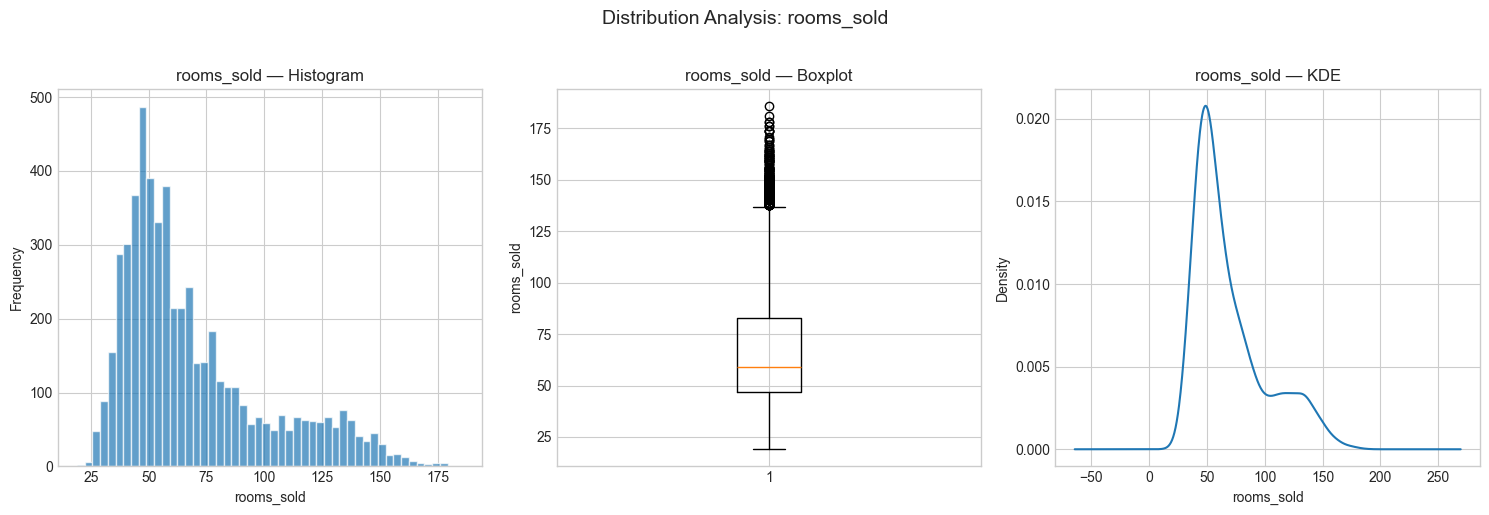

In [6]:
# Distribution plot
fig = eda_viz.plot_distributions(TARGET_COL)
plt.show()

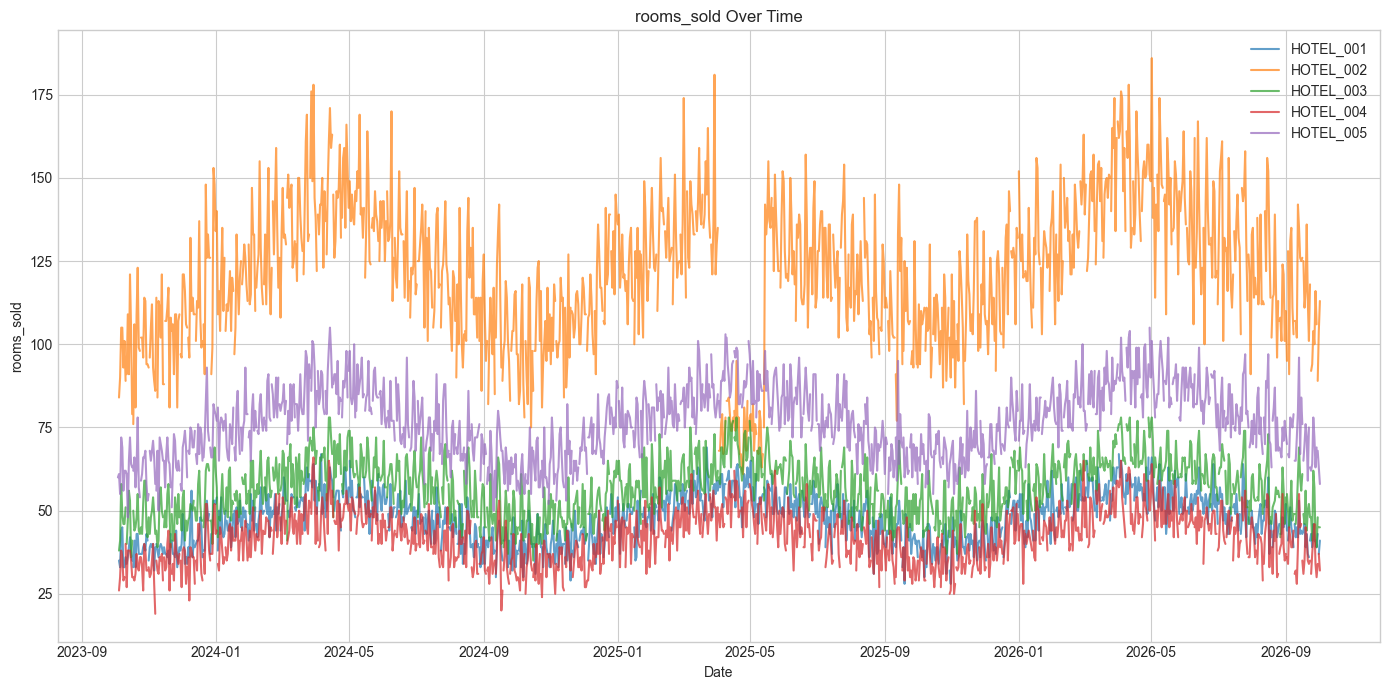

In [7]:
# Time series plot (per hotel)
fig = eda_viz.plot_time_series(TARGET_COL)
plt.show()

src.forecasting.eda.analyzer - INFO - Decomposition complete: model=additive, period=7


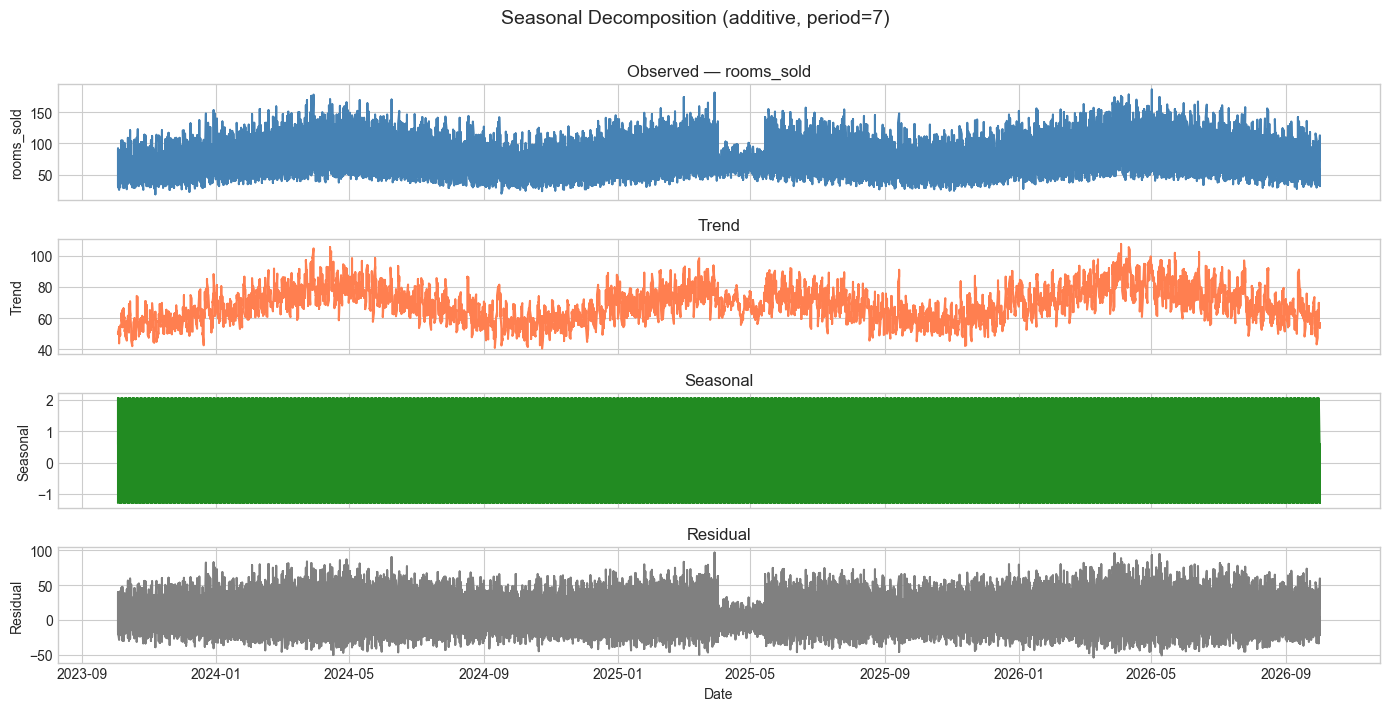

In [8]:
# Time series decomposition
decomp = eda.time_series_decomposition(TARGET_COL, period=7, model='additive')
fig = eda_viz.plot_decomposition(decomp, TARGET_COL)
plt.show()

In [9]:
# Stationarity tests
results = eda.stationarity_tests(TARGET_COL)
for r in results:
    print(f"  {r.test_name}: stat={r.statistic:.4f}, p={r.p_value:.4f} — {r.interpretation}")

C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\src\forecasting\eda\analyzer.py:263: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, p_val, n_lags, crit_vals = kpss(series, regression="c", nlags="auto")
src.forecasting.eda.analyzer - INFO - Augmented Dickey-Fuller: stat=-4.7073, p=0.0001 — Series IS stationary (reject unit root null)


src.forecasting.eda.analyzer - INFO - KPSS: stat=1.5965, p=0.0100 — Series is NOT stationary (reject stationarity null)


  Augmented Dickey-Fuller: stat=-4.7073, p=0.0001 — Series IS stationary (reject unit root null)
  KPSS: stat=1.5965, p=0.0100 — Series is NOT stationary (reject stationarity null)


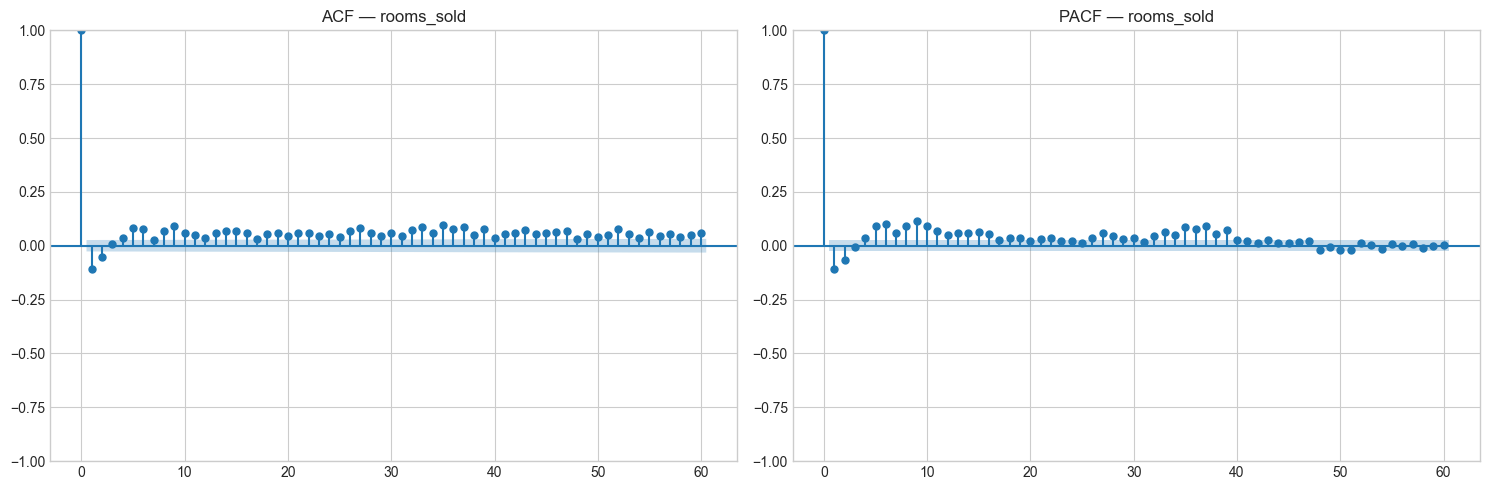

In [10]:
# ACF/PACF
fig = eda_viz.plot_acf_pacf(TARGET_COL, nlags=60)
plt.show()

In [11]:
# Seasonality detection
seasonality = eda.seasonality_detection(TARGET_COL)
for s in seasonality:
    print(f"  {s.pattern}: strength={s.strength:.3f}, p={s.p_value:.4f}")

src.forecasting.eda.analyzer - INFO - Seasonality — weekly: strength=0.002, p=0.0000


src.forecasting.eda.analyzer - INFO - Seasonality — monthly: strength=0.005, p=0.0000


src.forecasting.eda.analyzer - INFO - Seasonality — yearly: strength=0.006, p=0.0000


  weekly: strength=0.002, p=0.0000
  monthly: strength=0.005, p=0.0000
  yearly: strength=0.006, p=0.0000


src.forecasting.eda.analyzer - INFO - Outlier detection (iqr): 257 outliers (4.69%)


Outliers: 257 (4.69%)


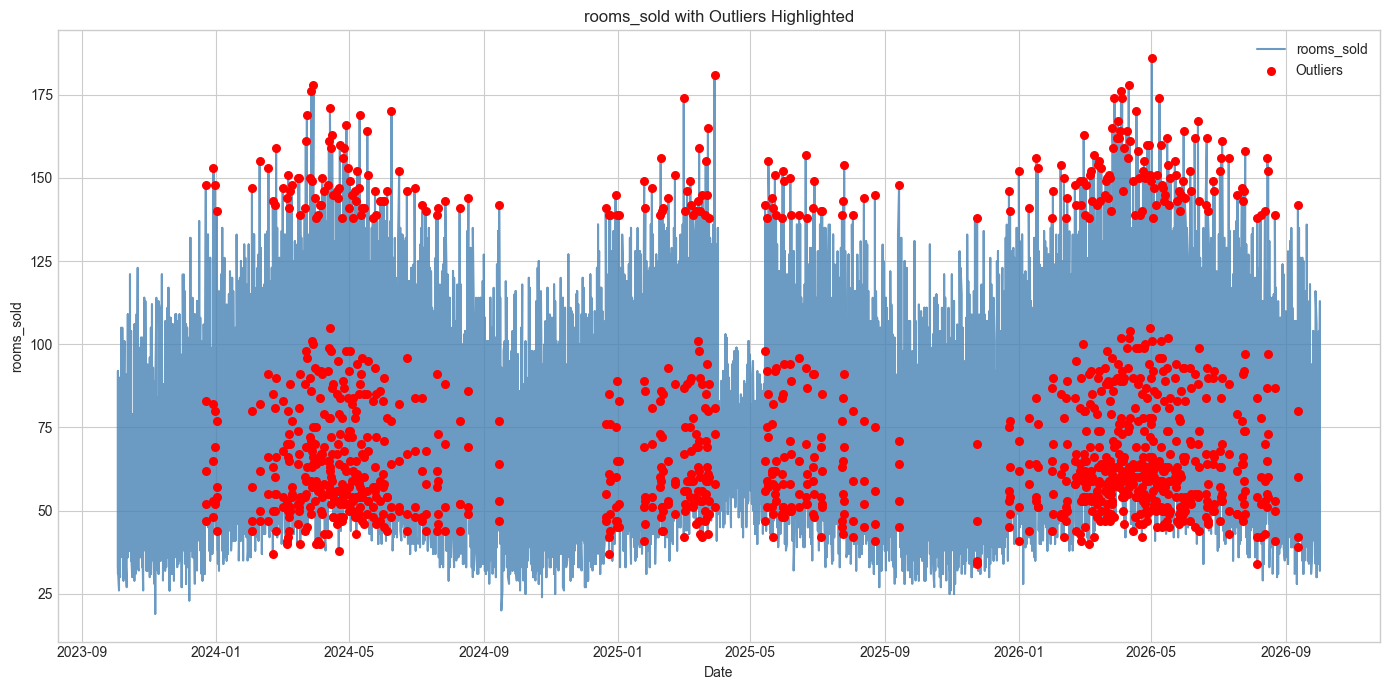

In [12]:
# Outlier detection
outlier_result = eda.outlier_detection(TARGET_COL, method='iqr', threshold=1.5)
print(f"Outliers: {outlier_result.n_outliers} ({outlier_result.outlier_pct}%)")
fig = eda_viz.plot_outliers(TARGET_COL, outlier_indices=outlier_result.outlier_indices)
plt.show()

src.forecasting.eda.analyzer - INFO - Correlation matrix computed (pearson) for 6 columns.


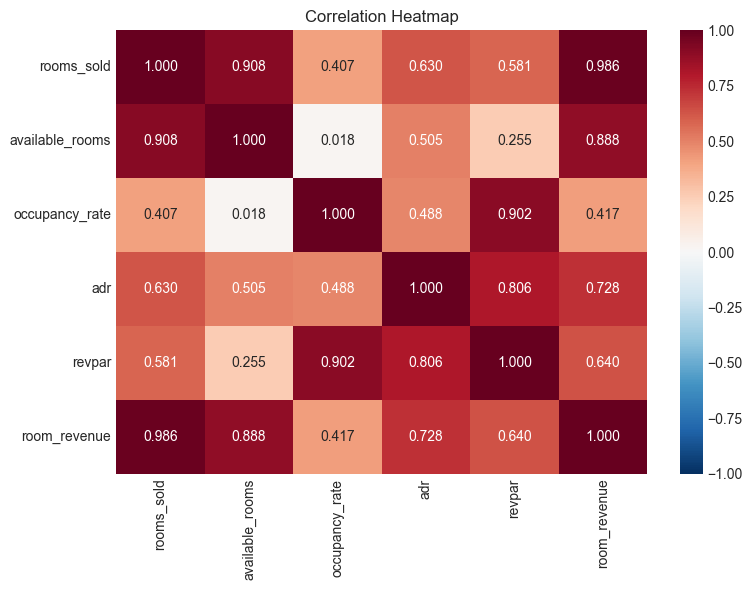

In [13]:
# Correlation analysis (understanding only — these are NOT ML features:
# their future values are unknown; see the forward-known rule in Section 5)
corr = eda.correlation_analysis(
    columns=[TARGET_COL, AVAIL_COL, 'occupancy_rate', 'adr', 'revpar', 'room_revenue']
)
fig = eda_viz.plot_correlation_heatmap(corr)
plt.show()

---
## Section 3: Preprocessing & Feature Engineering

**Módulo `preprocessing/` — diseño anti-fuga (leakage-safe)**

**Protocolo de números honestos:**
- **Agregación NULL-safe**: la serie diaria suma solo filas operacionales; los NULL de la tabla financiera se excluyen ANTES de imputar (nunca contaminan el target).
- El target **NO se escala** → métricas en room nights reales.
- Lags/rollings de `rooms_sold` calculados con `shift` (cada feature en `t` usa solo `t-1` o antes).
- Features monetarias (`revenue`, `room_revenue`) **excluidas de ML**: su futuro es desconocido (regla forward-known).
- `available_rooms` SÍ es feature: la capacidad es planeada por el hotel (forward-known).
- Split temporal 70/15/15 con gap de 7 días; evaluación del test **recursiva multi-paso**.

In [14]:
# ------------------------------------------------------------------
# HONEST EVALUATION PROTOCOL (same as the revenue pipeline)
#   1. All models on the SAME series: daily portfolio room nights.
#   2. Every test prediction is MULTI-STEP (only pre-test information).
#   3. ML models evaluated RECURSIVELY: predictions feed back as lags.
#   4. SeasonalNaive baseline included: models must beat it to be useful.
# ------------------------------------------------------------------

# NULL-safe daily aggregation (financial rows excluded BEFORE imputation)
df_agg, agg_report = aggregate_daily_target(
    df, target_col=TARGET_COL, date_col='date', sum_cols=[AVAIL_COL],
)
print(f"Aggregate series: {len(df_agg)} days | {df_agg['date'].min().date()} -> {df_agg['date'].max().date()}")
print(f"NULL-target rows excluded: {agg_report['n_excluded_null_rows']} | "
      f"gap dates: {agg_report['n_gap_dates']}")

pipeline = PreprocessingPipeline(
    missing_strategy=CONFIG['preprocessing']['missing_values']['strategy'],
    outlier_method=CONFIG['preprocessing']['outliers']['method'],
    outlier_action=CONFIG['preprocessing']['outliers']['action'],
    feature_config=RN['features'],          # target_cols: [rooms_sold]
    split_config=CONFIG['preprocessing']['split'],
    scale_method=None,                      # NO scaling: metrics in real room nights
    target_cols=[TARGET_COL],
)

split_result, train_feat, val_feat, test_feat = pipeline.run(df_agg, date_col='date')

print(f"Train: {len(train_feat)}d | Val: {len(val_feat)}d | Test: {len(test_feat)}d | "
      f"gap={split_result.gap_days}d")
print(f"train_end={split_result.train_end.date()}  val_end={split_result.val_end.date()}")

keep = ['date', TARGET_COL, AVAIL_COL]
train_df = train_feat[keep].copy()
val_df = val_feat[keep].copy()
test_df = test_feat[keep].copy()

test_start = test_df['date'].min()
actuals_test = test_df[TARGET_COL].values
test_dates = pd.to_datetime(test_df['date'])

# ALL observations strictly before the test window (contiguous calendar series)
history_eval = df_agg.loc[df_agg['date'] < test_start, ['date', TARGET_COL, AVAIL_COL]].reset_index(drop=True)
full_history = df_agg[keep].copy()

print(f"History available at test time: {len(history_eval)} days "
      f"(ends {history_eval['date'].max().date()})")

src.forecasting.data.aggregation - INFO - Daily aggregation of 'rooms_sold': 1095 days | 785 NULL-target rows excluded | 0 gap dates reindexed to NaN


src.forecasting.preprocessing.splitter - INFO - Temporal split: train=766, val=157, test=158 (gap=7 days)


src.forecasting.preprocessing.splitter - INFO - Split dates: train_end=2025-11-07, val_end=2026-04-20


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


Aggregate series: 1095 days | 2023-10-04 -> 2026-10-02
NULL-target rows excluded: 785 | gap dates: 0


...

src.forecasting.preprocessing.outliers - INFO - Outliers in 'available_rooms': 42 (5.48%) — action: flag


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 1 (0.64%) — action: flag


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 1 (0.63%) — action: flag


src.forecasting.preprocessing.pipeline - INFO - Pipeline complete: train=766 rows/50 cols, val=157, test=158


Train: 766d | Val: 157d | Test: 158d | gap=7d
train_end=2025-11-07  val_end=2026-04-20
History available at test time: 937 days (ends 2026-04-27)


In [15]:
# Show engineered features for the room-nights target
feature_cols_all = [
    c for c in train_feat.columns
    if c not in ('date', 'hotel_id', TARGET_COL, 'revenue', 'room_revenue')
]
print(f"Engineered features ({len(feature_cols_all)}):")
for i, col in enumerate(feature_cols_all, 1):
    print(f"  {i:2d}. {col}")

Engineered features (48):
   1. available_rooms
   2. year
   3. quarter
   4. month
   5. week
   6. day
   7. dayofweek
   8. dayofyear
   9. is_weekend
  10. is_month_start
  11. is_month_end
  12. is_quarter_start
  13. is_quarter_end
  14. dayofweek_sin
  15. dayofweek_cos
  16. dayofyear_sin
  17. dayofyear_cos
  18. month_sin
  19. month_cos
  20. rooms_sold_lag_1
  21. rooms_sold_lag_7
  22. rooms_sold_lag_14
  23. rooms_sold_lag_30
  24. rooms_sold_lag_365
  25. rooms_sold_rmean_7
  26. rooms_sold_rstd_7
  27. rooms_sold_rmin_7
  28. rooms_sold_rmax_7
  29. rooms_sold_rmean_14
  30. rooms_sold_rstd_14
  31. rooms_sold_rmin_14
  32. rooms_sold_rmax_14
  33. rooms_sold_rmean_30
  34. rooms_sold_rstd_30
  35. rooms_sold_rmin_30
  36. rooms_sold_rmax_30
  37. rooms_sold_rmean_90
  38. rooms_sold_rstd_90
  39. rooms_sold_rmin_90
  40. rooms_sold_rmax_90
  41. rooms_sold_emean
  42. rooms_sold_estd
  43. is_holiday
  44. is_pre_holiday
  45. is_post_holiday
  46. days_to_holiday
  4

---
## Section 4: Statistical Models

**Módulo `models/statistical/` — modelos de estructura explícita**

**Buenas prácticas comunes**: entrenados con **toda la historia previa al test** (serie continua) y evaluados con predicciones **multi-paso alineadas por fecha** — el mismo escenario de producción.

| Modelo | Qué es | Por qué funciona (o no) aquí |
|---|---|---|
| **Prophet** | Tendencia flexible + estacionalidad semanal/anual (Fourier) + festivos CR | Ideal para horizontes largos: proyecta componentes globales de un tirón |
| **SARIMAX** | ARIMA estacional con auto_arima por AIC | Fuerte a corto plazo; en 158 días puede derivar si no elige componente estacional |
| **ETS (Holt-Winters)** | Suavizado exponencial con selección por AIC | Robusto y parsimonioso |
| **SeasonalNaive** | Repite la última semana | **Disciplina de baseline** |

In [16]:
# Statistical models see all observed days strictly before the test window
train_val_df = history_eval[['date', TARGET_COL]].copy()
print(f"Statistical training window: {len(train_val_df)} days, "
      f"ends {train_val_df['date'].max().date()}")

Statistical training window: 937 days, ends 2026-04-27


In [17]:
# --- Prophet ---
print("Training Prophet on the full pre-test history...")
prophet = ProphetForecaster(
    changepoint_prior_scale=CONFIG['models']['statistical']['prophet']['changepoint_prior_scale'],
    seasonality_prior_scale=CONFIG['models']['statistical']['prophet']['seasonality_prior_scale'],
)
prophet.fit(train_val_df, target_col=TARGET_COL, date_col='date')
prophet_result = prophet.predict(test_df, target_col=TARGET_COL, date_col='date')
print(f"Prophet: {len(prophet_result.predictions)} multi-step predictions")

cmdstanpy - DEBUG - cmd: where.exe tbb.dll
cwd: None


Training Prophet on the full pre-test history...


cmdstanpy - DEBUG - Adding TBB (C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\prophet\stan_model\cmdstan-2.33.1\stan\lib\stan_math\lib\tbb) to PATH


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpic9ub2ac\lm26ppal.json


cmdstanpy - DEBUG - input tempfile: C:\Users\RIGOBE~1\AppData\Local\Temp\tmpic9ub2ac\osoviqqc.json


...

cmdstanpy - INFO - Chain [1] start processing


11:12:10 - cmdstanpy - INFO - Chain [1] done processing


cmdstanpy - INFO - Chain [1] done processing


src.forecasting.models.statistical.prophet_model - INFO - Prophet fitted in 0.31 seconds on 937 rows.


Prophet: 158 multi-step predictions


In [18]:
# --- SARIMAX ---
print("Training SARIMAX (auto_arima, weekly seasonality)...")
sarimax = SARIMAXForecaster(
    seasonal_periods=CONFIG['models']['statistical']['sarimax']['seasonal_periods'],
    stepwise=CONFIG['models']['statistical']['sarimax']['stepwise'],
)
sarimax.fit(train_val_df, target_col=TARGET_COL, date_col='date')
print(f"  order={sarimax._order}, seasonal_order={sarimax._seasonal_order}")
sarimax_result = sarimax.predict(test_df, target_col=TARGET_COL, date_col='date')
print(f"SARIMAX: {len(sarimax_result.predictions)} date-aligned multi-step predictions")

Training SARIMAX (auto_arima, weekly seasonality)...


src.forecasting.models.statistical.sarimax_model - INFO - SARIMAX fitted in 49.56 sec: order=(2, 1, 1), seasonal_order=(2, 0, 0, 7)


  order=(2, 1, 1), seasonal_order=(2, 0, 0, 7)
SARIMAX: 158 date-aligned multi-step predictions


In [19]:
# --- ETS (Holt-Winters) ---
print("Training ETS (auto selection by AIC)...")
ets = ETSForecaster(seasonal_periods=7, damped_trend=True, auto_select=True)
ets.fit(train_val_df, target_col=TARGET_COL, date_col='date')
print(f"  selected: {ets._model_params}")
ets_result = ets.predict(test_df, target_col=TARGET_COL, date_col='date')
print(f"ETS: {len(ets_result.predictions)} date-aligned multi-step predictions")

C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\ba

Training ETS (auto selection by AIC)...


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Users\Rigoberto\OneDrive - Enjoy Costa Rica E.G.C.R S A\Documentos\Proyectos\Forescaste\openspec\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


src.forecasting.models.statistical.ets_model - INFO - ETS fitted in 1.22 sec: params={'trend': None, 'seasonal': 'add', 'damped_trend': False, 'aic': 5559.944319688527}, AIC=5559.94


  selected: {'trend': None, 'seasonal': 'add', 'damped_trend': False, 'aic': 5559.944319688527}
ETS: 158 date-aligned multi-step predictions


SeasonalNaive: 158 predictions (last observed week cycled)


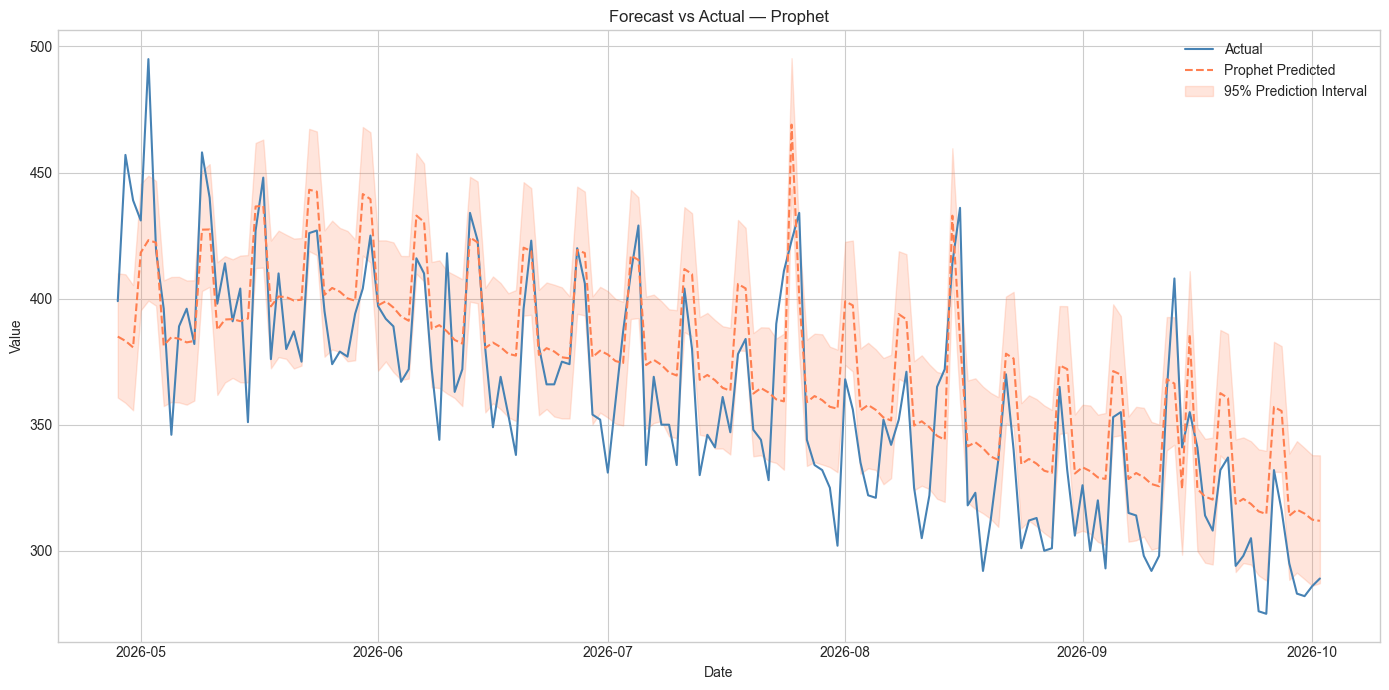

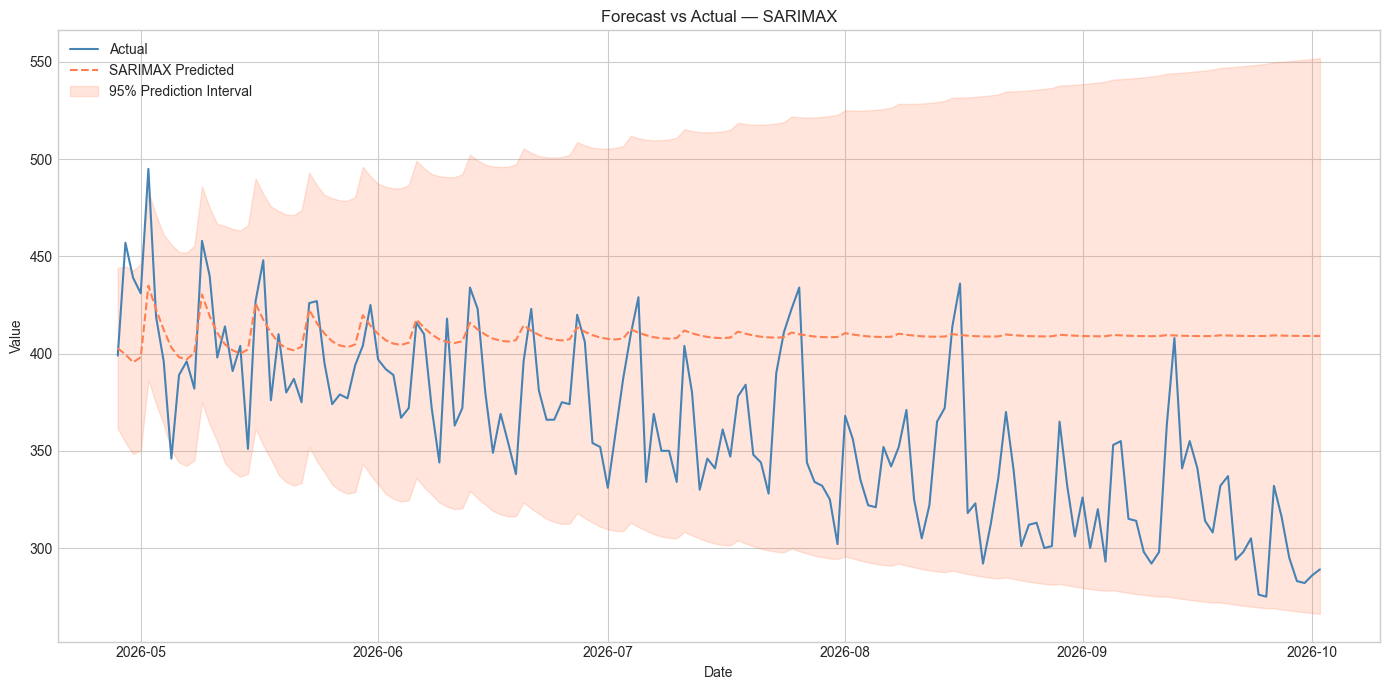

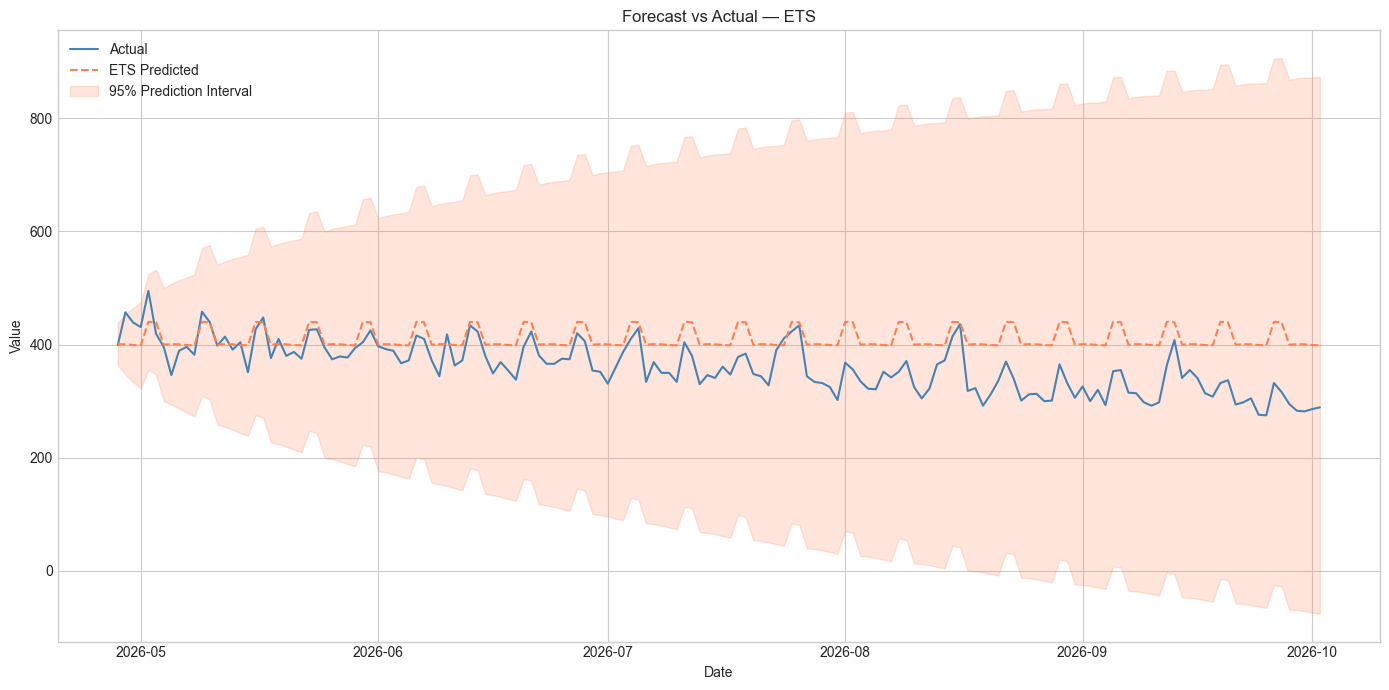

In [20]:
# --- Seasonal Naive baseline ---
last_week = history_eval[TARGET_COL].values[-7:]
naive_preds = np.array([last_week[i % 7] for i in range(len(test_df))])
print(f"SeasonalNaive: {len(naive_preds)} predictions (last observed week cycled)")

# Visualize statistical model forecasts
eval_viz = EvaluationVisualizer()
for name, result in [('Prophet', prophet_result), ('SARIMAX', sarimax_result), ('ETS', ets_result)]:
    fig = eval_viz.plot_forecast(
        result.actuals, result.predictions, dates=test_dates,
        model_name=name, lower_bound=result.lower_bound, upper_bound=result.upper_bound,
    )
    plt.show()

---
## Section 5: Machine Learning Models

**Módulo `models/ml/` — Gradient Boosting (LightGBM, XGBoost, CatBoost)**

**Protocolo honesto en 3 pasos por modelo:**
1. **Fit en train + early stopping en val** → iteraciones óptimas elegidas sin tocar el test.
2. **Refit en TODA la historia pre-test** con el nº de iteraciones ya fijado.
3. **Predicción recursiva del test**: cada predicción se realimenta como lag — los reales del test jamás son entradas.

**Regla forward-known aplicada:**
- Features = lags/rollings/expanding de `rooms_sold` + calendario + festivos CR + `available_rooms` (capacidad planeada → conocida a futuro, se arrastra con el último valor observado).
- **Excluidas**: toda feature derivada de `revenue`/`room_revenue` (ADR/RevPAR/occupancy realizados) — su valor futuro no existe; usarlas obligaría a inventar entradas fantasma.

In [21]:
# ML features: rooms_sold family + calendar + holidays + available_rooms.
# Monetary families excluded (future unknown) per the forward-known rule.
excluded_prefixes = tuple(RN['excluded_feature_prefixes'])
drop_cols = ['date', 'hotel_id', TARGET_COL] + list(excluded_prefixes)
feature_cols_ml = [
    c for c in train_feat.columns
    if c not in drop_cols
    and not c.startswith(excluded_prefixes)
    and not c.startswith('occupancy_rate')
    and not c.startswith('adr')
    and not c.startswith('revpar')
]
assert AVAIL_COL in feature_cols_ml, "available_rooms (forward-known) must be an ML feature"
print(f"ML features ({len(feature_cols_ml)}):")
print(feature_cols_ml)

ML features (48):
['available_rooms', 'year', 'quarter', 'month', 'week', 'day', 'dayofweek', 'dayofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'dayofweek_sin', 'dayofweek_cos', 'dayofyear_sin', 'dayofyear_cos', 'month_sin', 'month_cos', 'rooms_sold_lag_1', 'rooms_sold_lag_7', 'rooms_sold_lag_14', 'rooms_sold_lag_30', 'rooms_sold_lag_365', 'rooms_sold_rmean_7', 'rooms_sold_rstd_7', 'rooms_sold_rmin_7', 'rooms_sold_rmax_7', 'rooms_sold_rmean_14', 'rooms_sold_rstd_14', 'rooms_sold_rmin_14', 'rooms_sold_rmax_14', 'rooms_sold_rmean_30', 'rooms_sold_rstd_30', 'rooms_sold_rmin_30', 'rooms_sold_rmax_30', 'rooms_sold_rmean_90', 'rooms_sold_rstd_90', 'rooms_sold_rmin_90', 'rooms_sold_rmax_90', 'rooms_sold_emean', 'rooms_sold_estd', 'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'days_to_holiday', 'rooms_sold_outlier', 'available_rooms_outlier']


In [22]:
FUTURE_KNOWN = [AVAIL_COL]  # capacity is planned: carried through recursion

def fit_gbm_honest(model_obj, name):
    """3-step honest GBM protocol: ES on val -> refit pre-test history -> recursive test forecast."""
    print(f"Training {name} (early stopping on val)...")
    model_obj.fit(train_feat, target_col=TARGET_COL, date_col='date',
                  feature_cols=feature_cols_ml, val_df=val_feat)
    print(f"  best_iteration={model_obj.best_iteration()}")

    # Refit on ALL pre-test data with the fixed iteration count
    hist_feat = pipeline.feature_engineer.transform(history_eval)
    hist_feat = pipeline.holiday_engineer.transform(hist_feat)
    hist_feat = pipeline.outlier_handler.transform(hist_feat)
    model_obj.final_refit(hist_feat, target_col=TARGET_COL, date_col='date',
                          feature_cols=feature_cols_ml)

    # Recursive multi-step forecast: predictions feed back as lags;
    # available_rooms rides along with its last observed (planned) value.
    preds = recursive_forecast(
        model_obj, history_eval, test_dates,
        target_col=TARGET_COL, date_col='date',
        feature_cols=feature_cols_ml,
        feature_engineer=pipeline.feature_engineer,
        holiday_engineer=pipeline.holiday_engineer,
        future_known_cols=FUTURE_KNOWN,
    )
    print(f"  {name}: {len(preds)} recursive multi-step predictions")
    return preds

lgbm_params = {**LightGBMForecaster().params, **CONFIG['models']['ml']['lightgbm']}
for k in ('early_stopping_rounds', 'categorical_features'):
    lgbm_params.pop(k, None)
lgbm_params['n_estimators'] = 1000

lgbm = LightGBMForecaster(params=lgbm_params, early_stopping_rounds=50)
lgbm_preds = fit_gbm_honest(lgbm, 'LightGBM')

Training LightGBM (early stopping on val)...


src.forecasting.models.ml.lgbm_model - INFO - LightGBM fitted in 0.28 sec, best iteration: 116


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 3 (0.32%) — action: flag


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 50/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 100/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 158 steps (incremental path)


  LightGBM: 158 recursive multi-step predictions


In [23]:
# --- XGBoost ---
xgb_params = {**XGBoostForecaster().params, **CONFIG['models']['ml']['xgboost']}
xgb_params.pop('early_stopping_rounds', None)
xgb_params['n_estimators'] = 1000

xgb = XGBoostForecaster(params=xgb_params, early_stopping_rounds=50)
xgb_preds = fit_gbm_honest(xgb, 'XGBoost')

Training XGBoost (early stopping on val)...


src.forecasting.models.ml.xgb_model - INFO - XGBoost fitted in 0.42 sec.


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 3 (0.32%) — action: flag


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 50/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 100/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 158 steps (incremental path)


  XGBoost: 158 recursive multi-step predictions


In [24]:
# --- CatBoost ---
cat_params = {**CatBoostForecaster().params, **CONFIG['models']['ml']['catboost']}
for k in ('early_stopping_rounds', 'cat_features'):
    cat_params.pop(k, None)
cat_params['iterations'] = 1000

cat = CatBoostForecaster(params=cat_params, early_stopping_rounds=50)
cat_preds = fit_gbm_honest(cat, 'CatBoost')

Training CatBoost (early stopping on val)...


src.forecasting.models.ml.catboost_model - INFO - CatBoost fitted in 0.63 sec.


src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 3 (0.32%) — action: flag


...

src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 50/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 100/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 150/158 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 158 steps (incremental path)


  CatBoost: 158 recursive multi-step predictions


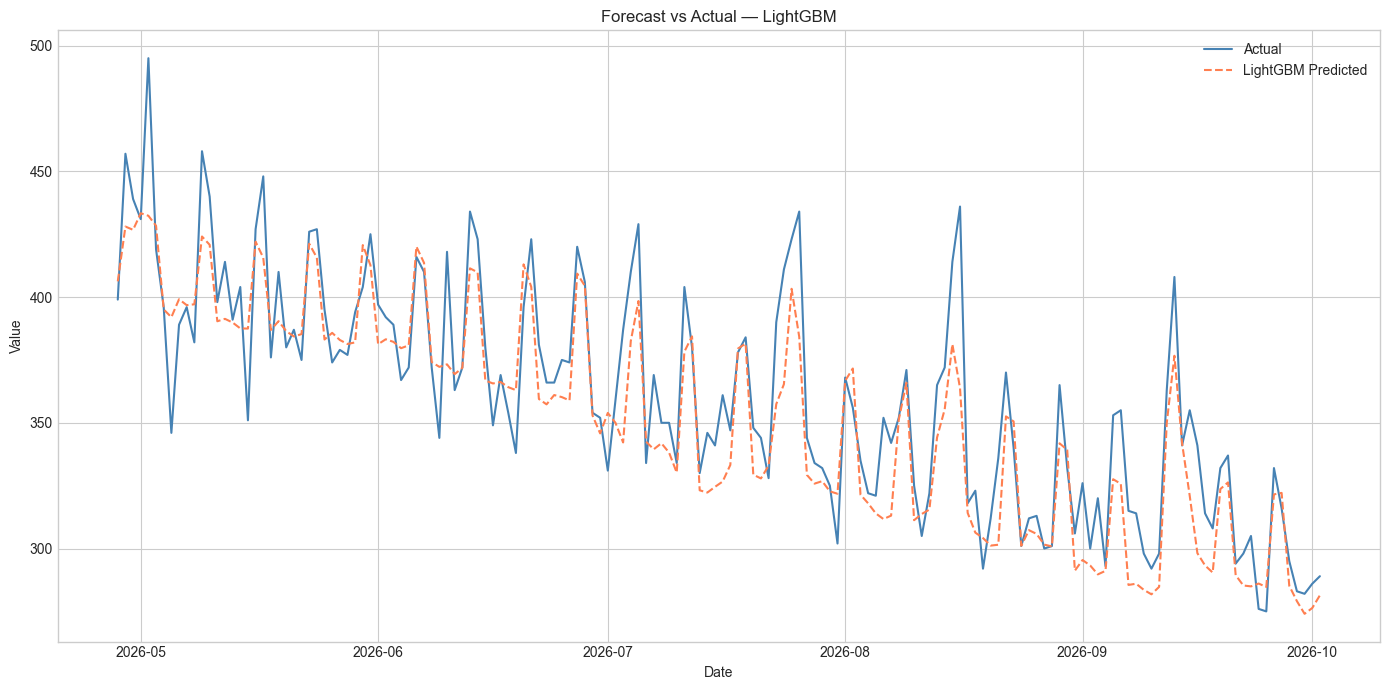

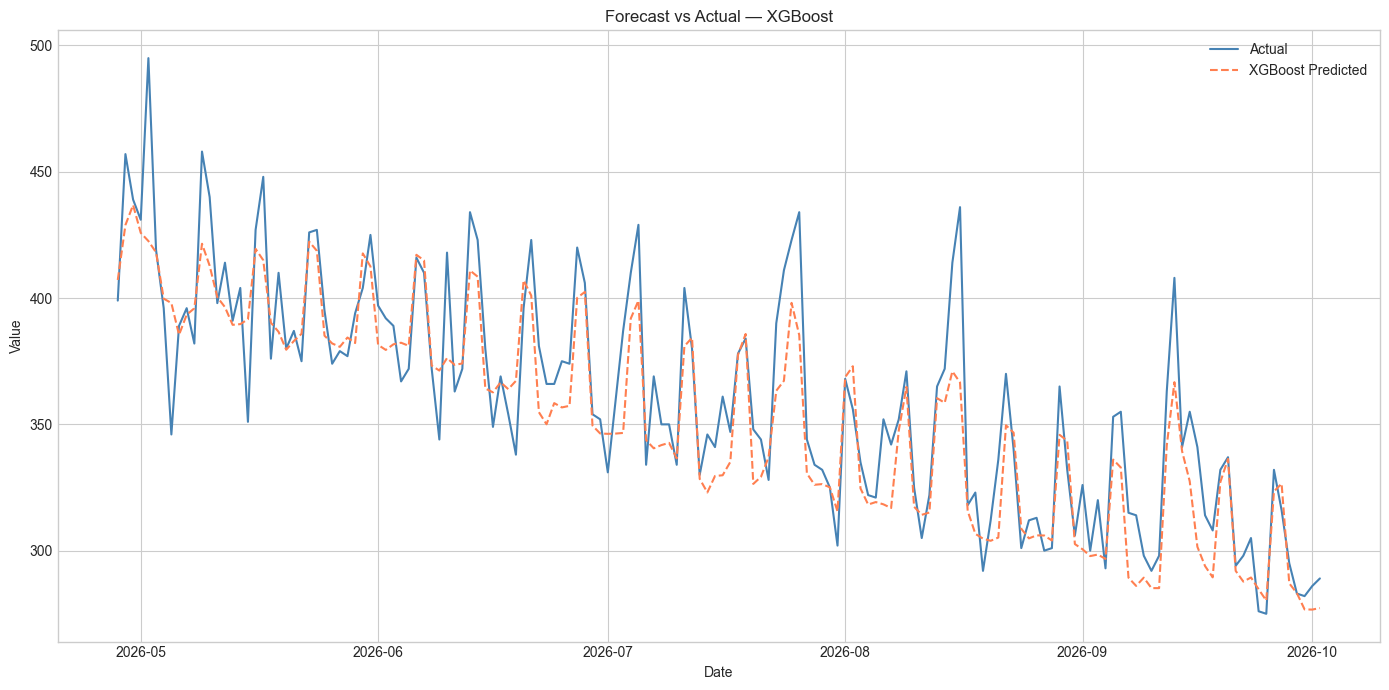

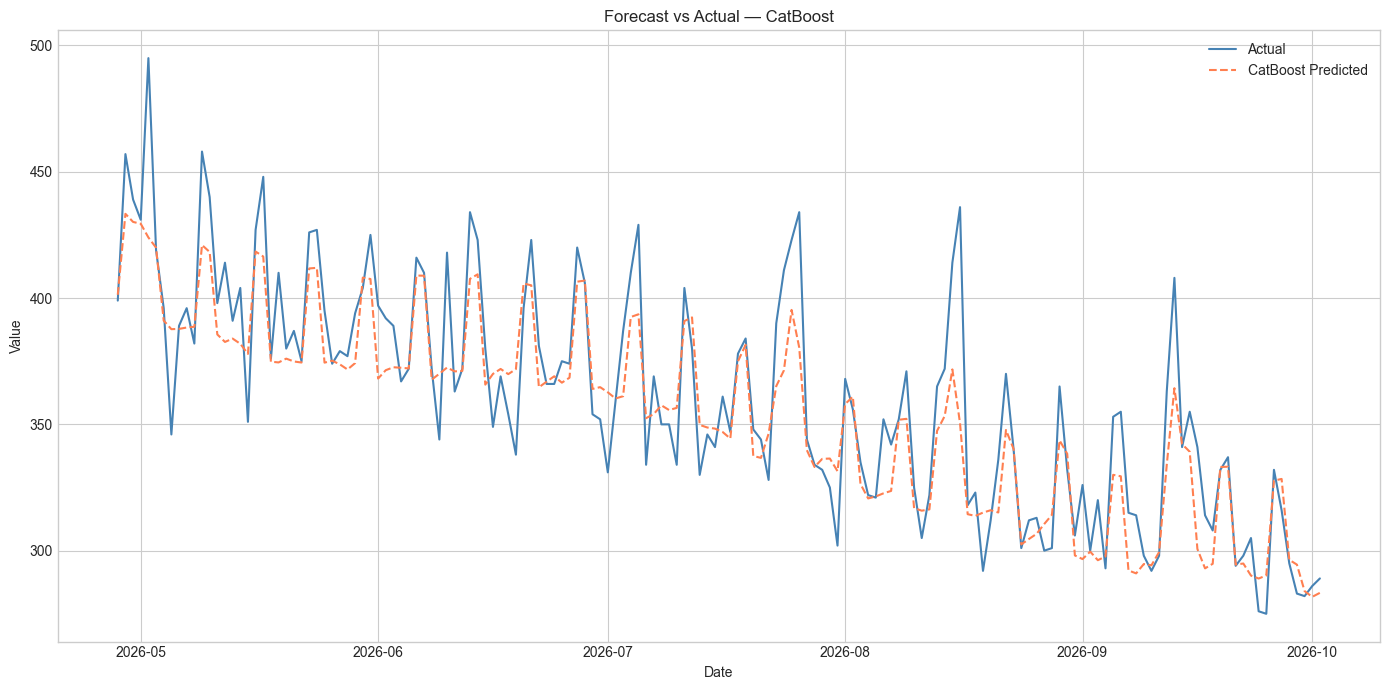

In [25]:
# Visualize ML forecasts (recursive multi-step)
for name, preds in [('LightGBM', lgbm_preds), ('XGBoost', xgb_preds), ('CatBoost', cat_preds)]:
    fig = eval_viz.plot_forecast(actuals_test, preds, dates=test_dates, model_name=name)
    plt.show()

---
## Section 6: Deep Learning Models

**Módulo `models/dl/`**

| Modelo | Enfoque | Veredicto honesto |
|---|---|---|
| **PatchTST** | Transformer con parches de 16 días; entrenado con split temporal interno; evaluado con pronóstico multi-ventana recursivo | Prometedor, pero con ~900 días de una serie tiene pocos ejemplos |
| **TimesFM** | Modelo fundacional de Google (zero-shot) | **Excluido en Windows** (requiere JAX/lingvo, Linux). Su fallback NO se reporta bajo su nombre — se reporta la ausencia |

**Lección de especialista**: la complejidad se gana con datos, no se presupone.

In [26]:
# --- TimesFM: availability check (honest exclusion) ---
try:
    import timesfm  # noqa: F401
    TIMESFM_AVAILABLE = True
    print("TimesFM available.")
except ImportError:
    TIMESFM_AVAILABLE = False
    print("TimesFM NOT available on this platform (requires Linux/JAX).")
    print("Excluded from the comparison — running its naive fallback under the")
    print("name 'TimesFM' would produce misleading numbers.")

TimesFM NOT available on this platform (requires Linux/JAX).
Excluded from the comparison — running its naive fallback under the
name 'TimesFM' would produce misleading numbers.


Training PatchTST (internal temporal split for early stopping)...


src.forecasting.models.dl.patchtst_model - INFO - Early stopping at epoch 9


src.forecasting.models.dl.patchtst_model - INFO - PatchTST fitted in 3.44 sec.


PatchTST: 158 recursive multi-window predictions


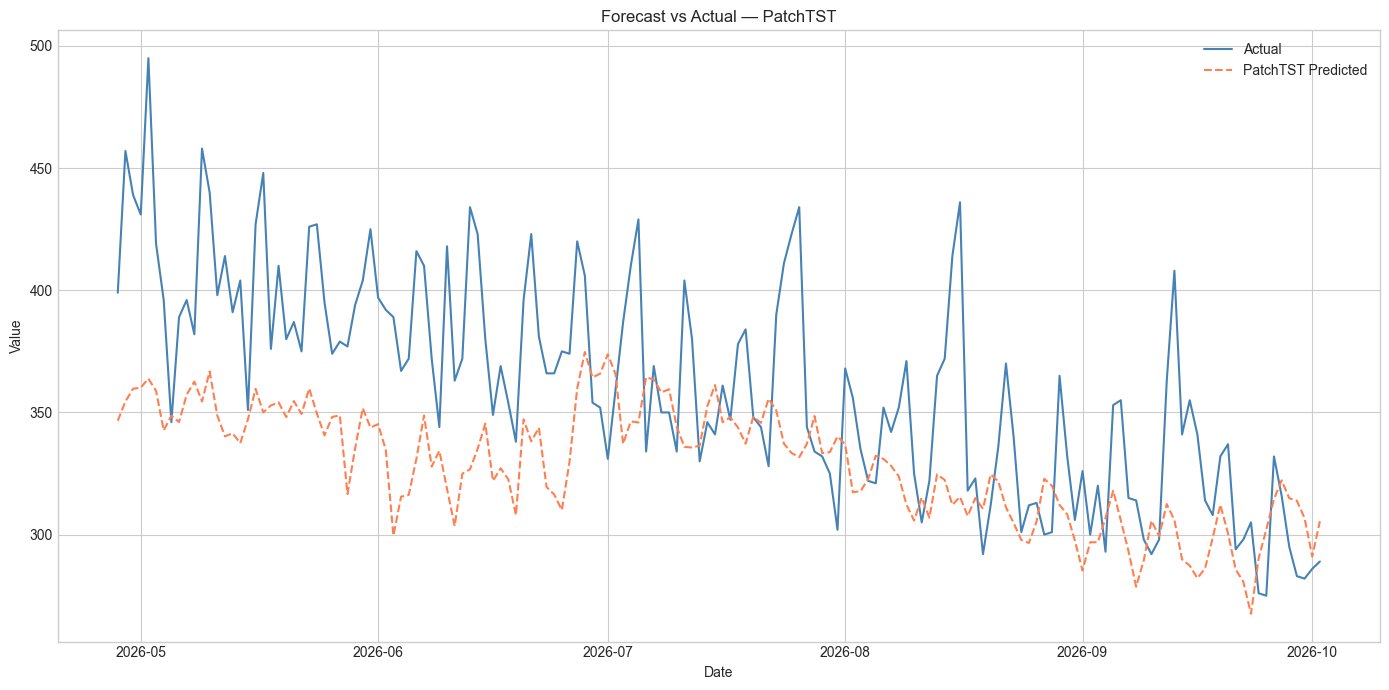

In [27]:
# --- PatchTST ---
print("Training PatchTST (internal temporal split for early stopping)...")
pt_cfg = CONFIG['models']['dl']['patchtst']
patchtst = PatchTSTForecaster(
    patch_len=pt_cfg['patch_len'], stride=pt_cfg['stride'],
    d_model=pt_cfg['d_model'], n_heads=pt_cfg['n_heads'],
    n_layers=pt_cfg['n_layers'], epochs=pt_cfg['epochs'],
    batch_size=pt_cfg['batch_size'], patience=pt_cfg['patience'],
    context_len=256, horizon=30,
)
n_val_pt = max(60, int(len(history_eval) * 0.10))
patchtst.fit(history_eval.iloc[:-n_val_pt][['date', TARGET_COL]],
             target_col=TARGET_COL, date_col='date',
             val_df=history_eval.iloc[-n_val_pt:][['date', TARGET_COL]])
patchtst_result = patchtst.predict(
    test_df, target_col=TARGET_COL, date_col='date',
    context_df=history_eval[['date', TARGET_COL]],
)
print(f"PatchTST: {len(patchtst_result.predictions)} recursive multi-window predictions")

fig = eval_viz.plot_forecast(actuals_test, patchtst_result.predictions, dates=test_dates,
                             model_name='PatchTST')
plt.show()

---
## Section 7: Final Comparison & Evaluation

**Módulo `evaluation/` — cómo leer la tabla**

**Guía de métricas:**
- **MAE** (room nights): error diario promedio — "me equivoqué en X habitaciones/día".
- **RMSE**: castiga errores grandes; RMSE >> MAE = días puntuales de desvío severo.
- **WAPE** (%): error total ÷ demanda total → "de cada 100 noches vendidas, me equivoqué en X".
- **MASE**: error ÷ error del naive estacional. **El juez más justo**: <1 supera al baseline.

**Rigor estadístico:** misma serie y ventana para todos; **Diebold-Mariano con varianza Newey-West (h=7)** compensa la autocorrelación de errores multi-paso; baseline SeasonalNaive incluido.

In [28]:
# Evaluate all models on the SAME series and window
evaluator = Evaluator()

all_results = {
    'SeasonalNaive': (actuals_test, naive_preds),
    'Prophet': (actuals_test, prophet_result.predictions),
    'SARIMAX': (actuals_test, sarimax_result.predictions),
    'ETS': (actuals_test, ets_result.predictions),
    'LightGBM': (actuals_test, lgbm_preds),
    'XGBoost': (actuals_test, xgb_preds),
    'CatBoost': (actuals_test, cat_preds),
    'PatchTST': (actuals_test, patchtst_result.predictions),
}

metrics_results = evaluator.compute_all_metrics(
    all_results, split='test', naive_forecast=naive_preds
)
comparison_df = evaluator.comparison_table(metrics_results)
print("=== Model Comparison — Test Set (multi-step, room nights) ===")
display(comparison_df.round(2))

src.forecasting.evaluation.evaluator - INFO - SeasonalNaive (test): MAE=49.87, RMSE=60.32, MAPE=15.01%, WAPE=13.80%


src.forecasting.evaluation.evaluator - INFO - Prophet (test): MAE=22.67, RMSE=26.71, MAPE=6.48%, WAPE=6.27%


src.forecasting.evaluation.evaluator - INFO - SARIMAX (test): MAE=53.58, RMSE=64.83, MAPE=16.25%, WAPE=14.83%


src.forecasting.evaluation.evaluator - INFO - ETS (test): MAE=52.94, RMSE=63.31, MAPE=15.95%, WAPE=14.65%


src.forecasting.evaluation.evaluator - INFO - LightGBM (test): MAE=15.21, RMSE=19.82, MAPE=4.15%, WAPE=4.21%


src.forecasting.evaluation.evaluator - INFO - XGBoost (test): MAE=14.48, RMSE=19.41, MAPE=3.92%, WAPE=4.01%


src.forecasting.evaluation.evaluator - INFO - CatBoost (test): MAE=14.32, RMSE=19.72, MAPE=3.86%, WAPE=3.96%


src.forecasting.evaluation.evaluator - INFO - PatchTST (test): MAE=39.35, RMSE=48.84, MAPE=10.28%, WAPE=10.89%


=== Model Comparison — Test Set (multi-step, room nights) ===


,N,MAE,RMSE,MAPE,sMAPE,MASE,WAPE
Model,,,,,,,
SeasonalNaive,158,49.87,60.32,15.01,13.49,1.00,13.80
Prophet,158,22.67,26.71,6.48,6.30,0.45,6.27
SARIMAX,158,53.58,64.83,16.25,14.47,1.07,14.83
ETS,158,52.94,63.31,15.95,14.25,1.06,14.65
LightGBM,158,15.21,19.82,4.15,4.25,0.30,4.21
XGBoost,158,14.48,19.41,3.92,4.00,0.29,4.01
CatBoost,158,14.32,19.72,3.86,3.93,0.29,3.96
PatchTST,158,39.35,48.84,10.28,11.02,0.79,10.89


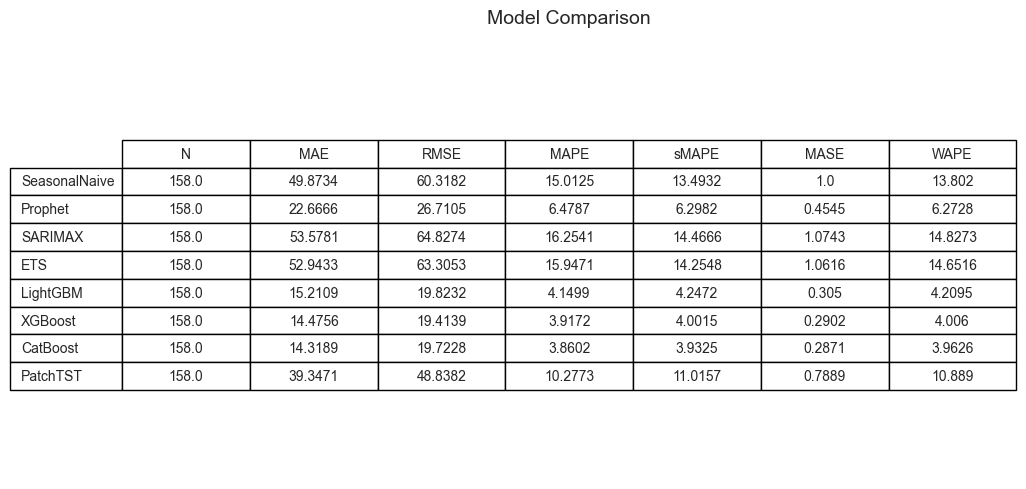

In [29]:
# Comparison visualization
fig = eval_viz.plot_comparison_table(comparison_df)
plt.show()

In [30]:
# Rank models by primary metric
comparison = evaluator.compare_models(metrics_results, primary_metric='MAE')
print(f"\nBest model (by MAE): {comparison.best_model}")
print(f"\nRankings by MAE: {comparison.rankings.get('MAE', [])}")

src.forecasting.evaluation.evaluator - INFO - Best model by MAE: CatBoost



Best model (by MAE): CatBoost

Rankings by MAE: ['CatBoost', 'XGBoost', 'LightGBM', 'Prophet', 'PatchTST', 'SeasonalNaive', 'ETS', 'SARIMAX']


In [31]:
# Diebold-Mariano: best model vs each competitor (Newey-West h=7)
ranked = comparison.rankings.get('MAE', [])
model_a = ranked[0]
print(f"DM tests (best by MAE): {model_a} vs each competitor")

dm_rows = []
for other in ranked[1:]:
    dm = evaluator.diebold_mariano_test(
        actuals_test, all_results[model_a][1], all_results[other][1], h=7, power=1
    )
    dm_rows.append({
        'Competitor': other,
        'DM': dm['dm_statistic'],
        'p-value': dm['p_value'],
        'Better & significant': bool(dm['significant'] and dm['dm_statistic'] < 0),
    })
dm_df = pd.DataFrame(dm_rows).set_index('Competitor')
display(dm_df)

src.forecasting.evaluation.evaluator - INFO - DM test: stat=-0.2678, p=0.7892 — Not significant


DM tests (best by MAE): CatBoost vs each competitor


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-1.4922, p=0.1377 — Not significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-5.1338, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-8.2950, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-5.4911, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-5.6829, p=0.0000 — Significant


src.forecasting.evaluation.evaluator - INFO - DM test: stat=-6.0832, p=0.0000 — Significant


,DM,p-value,Better & significant
Competitor,,,
XGBoost,-0.2678,0.7892,False
LightGBM,-1.4922,0.1377,False
Prophet,-5.1338,0.0000,True
PatchTST,-8.2950,0.0000,True
SeasonalNaive,-5.4911,0.0000,True
ETS,-5.6829,0.0000,True
SARIMAX,-6.0832,0.0000,True


In [32]:
# Residual diagnostics for best model
best_name = comparison.best_model
actuals_best, preds_best = all_results[best_name]
diag = evaluator.residual_diagnostics(actuals_best, preds_best)
print(f"\nResidual Diagnostics — {best_name}:")
for test_name, result in diag.items():
    print(f"  {test_name}: {result}")

src.forecasting.evaluation.evaluator - INFO - Residual diagnostics: JB p=0.0000, LB min_p=0.0304



Residual Diagnostics — CatBoost:
  jarque_bera: {'statistic': 42.7267, 'p_value': 0.0}
  ljung_box: {'min_p_value': 0.0304}
  breusch_pagan: {'statistic': 0.392, 'p_value': 0.5312}
  residual_mean: 7.116
  residual_std: 18.3943


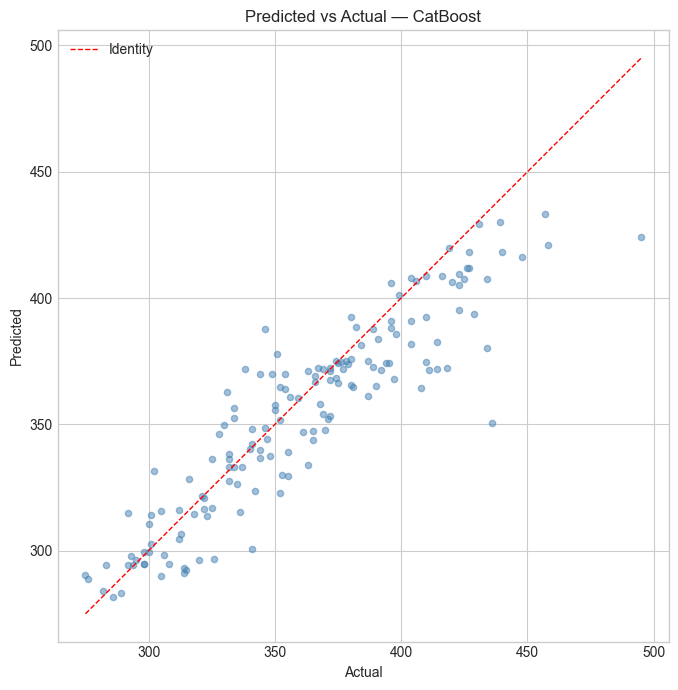

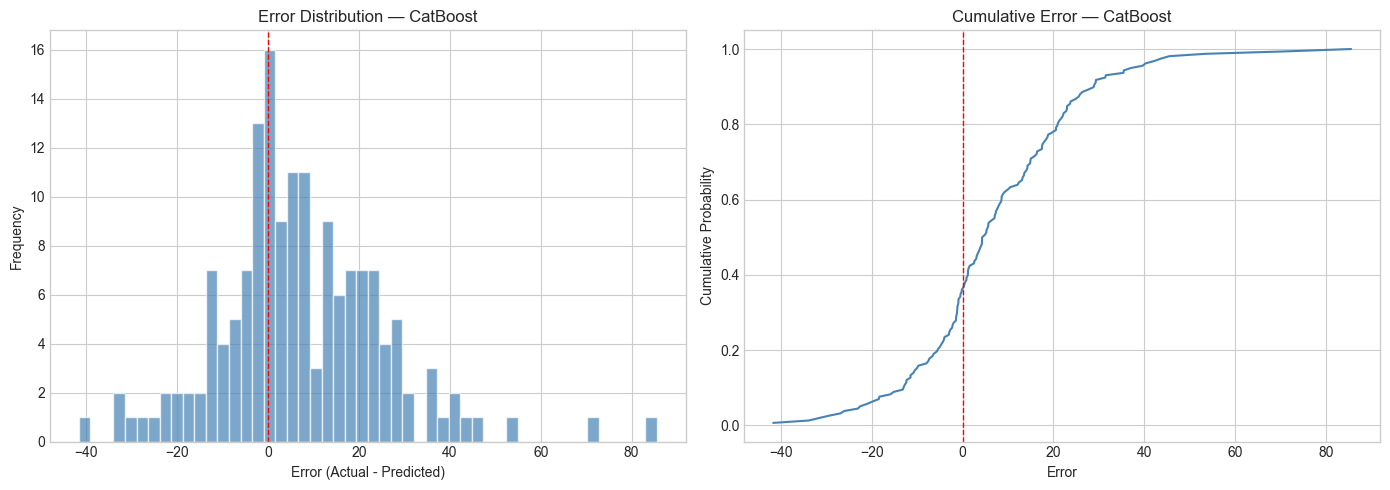

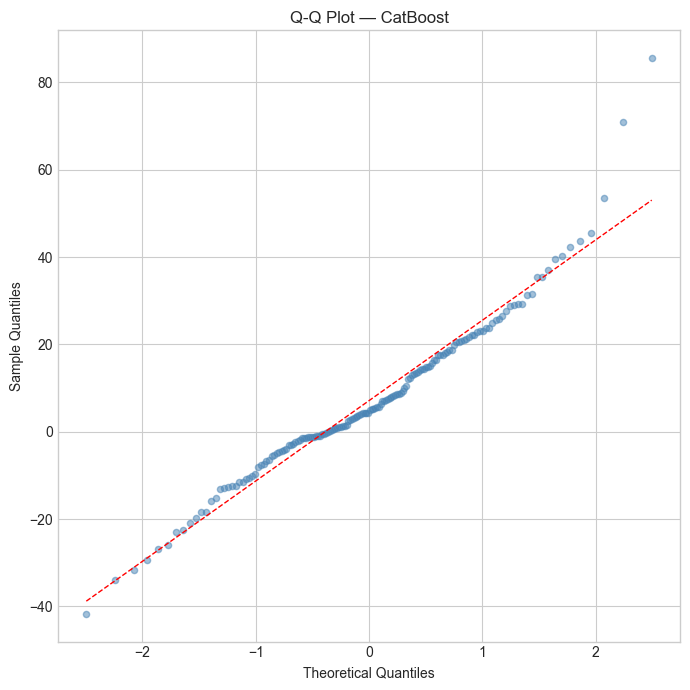

In [33]:
# Scatter and error distribution for best model
fig = eval_viz.plot_scatter(actuals_best, preds_best, model_name=best_name)
plt.show()

fig = eval_viz.plot_error_distribution(actuals_best, preds_best, model_name=best_name)
plt.show()

fig = eval_viz.plot_qq(actuals_best, preds_best, model_name=best_name)
plt.show()

---
## Section 8: Future Forecast

**Práctica estándar post-selección**: el modelo ganador se **reentrena con TODA la historia observada** y pronostica los próximos 90 días con la misma mecánica honesta (recursiva para ML, `available_rooms` forward-known).

**Novedad room nights — techo de capacidad:**
- El pronóstico se **recorta a la capacidad disponible** (`available_rooms`, portafolio = suma de hoteles).
- Se reporta la **ocupación implícita** (pronóstico ÷ capacidad) y los días recortados.
- Capacidad futura = último valor observado (suposición documentada: sin renovaciones anunciadas).

In [34]:
# ------------------------------------------------------------------
# FUTURE FORECAST: best model retrained on ALL observed data
# ------------------------------------------------------------------
horizon = CONFIG['forecasting']['horizon_days']
last_observed = full_history['date'].max()
future_dates = pd.date_range(last_observed + pd.Timedelta(days=1), periods=horizon, freq='D')
future_df = pd.DataFrame({'date': future_dates})

# Future capacity = last observed (documented assumption)
last_capacity = float(full_history[AVAIL_COL].iloc[-1])
future_capacity = pd.Series(np.full(horizon, last_capacity))

print(f"Best model: {best_name} | Forecasting {horizon} days from {future_dates[0].date()}")
print(f"Future capacity (last observed): {last_capacity:.0f} rooms/day")

future_lo = future_hi = None

gbm_map = {'LightGBM': lgbm, 'XGBoost': xgb, 'CatBoost': cat}

if best_name in gbm_map:
    model_obj = gbm_map[best_name]
    full_feat = pipeline.feature_engineer.transform(full_history)
    full_feat = pipeline.holiday_engineer.transform(full_feat)
    full_feat = pipeline.outlier_handler.transform(full_feat)
    model_obj.final_refit(full_feat, target_col=TARGET_COL, date_col='date',
                          feature_cols=feature_cols_ml)
    raw_future = recursive_forecast(
        model_obj, full_history, future_dates,
        target_col=TARGET_COL, date_col='date',
        feature_cols=feature_cols_ml,
        feature_engineer=pipeline.feature_engineer,
        holiday_engineer=pipeline.holiday_engineer,
        future_known_cols=FUTURE_KNOWN,
    )
elif best_name == 'SeasonalNaive':
    last_week_full = full_history[TARGET_COL].values[-7:]
    raw_future = np.array([last_week_full[i % 7] for i in range(horizon)])
elif best_name == 'Prophet':
    final_model = ProphetForecaster(
        changepoint_prior_scale=CONFIG['models']['statistical']['prophet']['changepoint_prior_scale'],
        seasonality_prior_scale=CONFIG['models']['statistical']['prophet']['seasonality_prior_scale'],
    )
    final_model.fit(full_history, target_col=TARGET_COL, date_col='date')
    fr = final_model.predict(future_df, target_col=TARGET_COL, date_col='date')
    raw_future, future_lo, future_hi = fr.predictions, fr.lower_bound, fr.upper_bound
elif best_name == 'SARIMAX':
    final_model = SARIMAXForecaster(
        seasonal_periods=CONFIG['models']['statistical']['sarimax']['seasonal_periods'],
        stepwise=CONFIG['models']['statistical']['sarimax']['stepwise'],
    )
    final_model.fit(full_history, target_col=TARGET_COL, date_col='date')
    fr = final_model.predict(future_df, target_col=TARGET_COL, date_col='date')
    raw_future, future_lo, future_hi = fr.predictions, fr.lower_bound, fr.upper_bound
elif best_name == 'ETS':
    final_model = ETSForecaster(seasonal_periods=7, damped_trend=True, auto_select=True)
    final_model.fit(full_history, target_col=TARGET_COL, date_col='date')
    fr = final_model.predict(future_df, target_col=TARGET_COL, date_col='date')
    raw_future, future_lo, future_hi = fr.predictions, fr.lower_bound, fr.upper_bound
elif best_name == 'PatchTST':
    final_model = PatchTSTForecaster(
        patch_len=pt_cfg['patch_len'], stride=pt_cfg['stride'],
        d_model=pt_cfg['d_model'], n_heads=pt_cfg['n_heads'],
        n_layers=pt_cfg['n_layers'], epochs=pt_cfg['epochs'],
        batch_size=pt_cfg['batch_size'], patience=pt_cfg['patience'],
        context_len=256, horizon=30,
    )
    n_val_f = max(60, int(len(full_history) * 0.10))
    final_model.fit(full_history.iloc[:-n_val_f][['date', TARGET_COL]],
                    target_col=TARGET_COL, date_col='date',
                    val_df=full_history.iloc[-n_val_f:][['date', TARGET_COL]])
    fr = final_model.predict(future_df, target_col=TARGET_COL, date_col='date',
                             context_df=full_history[['date', TARGET_COL]])
    raw_future = fr.predictions

assert len(raw_future) == horizon and not np.isnan(np.asarray(raw_future, dtype=float)).any()

# --- Capacity ceiling + implied occupancy ---
future_series = pd.Series(np.asarray(raw_future, dtype=float), index=future_dates)
future_preds, cap_report = apply_capacity_ceiling(future_series, future_capacity)
future_occ = implied_occupancy(future_preds, future_capacity)

print(f"\nTotal forecasted room nights ({horizon}d): {future_preds.sum():,.0f}")
print(f"Daily mean: {future_preds.mean():,.1f} room nights")
print(f"Implied occupancy: mean={future_occ.mean():.1%} | max={future_occ.max():.1%}")
print(f"Days capped by capacity: {len(cap_report)}")

src.forecasting.preprocessing.features - INFO - Feature engineering complete: 44 columns


src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.preprocessing.outliers - INFO - Outliers in 'rooms_sold': 4 (0.37%) — action: flag


src.forecasting.preprocessing.outliers - INFO - Outliers in 'available_rooms': 42 (3.84%) — action: flag


Best model: CatBoost | Forecasting 90 days from 2026-10-03
Future capacity (last observed): 550 rooms/day


...

src.forecasting.preprocessing.holidays - INFO - Holiday features added: is_holiday, is_pre_holiday, is_post_holiday, days_to_holiday


src.forecasting.forecasting.recursive - INFO - Incremental path verified (46 feature columns match the reference).


src.forecasting.forecasting.recursive - INFO - Recursive forecast (incremental): 50/90 steps


src.forecasting.forecasting.recursive - INFO - Recursive forecast complete: 90 steps (incremental path)



Total forecasted room nights (90d): 27,747
Daily mean: 308.3 room nights
Implied occupancy: mean=56.1% | max=67.2%
Days capped by capacity: 0


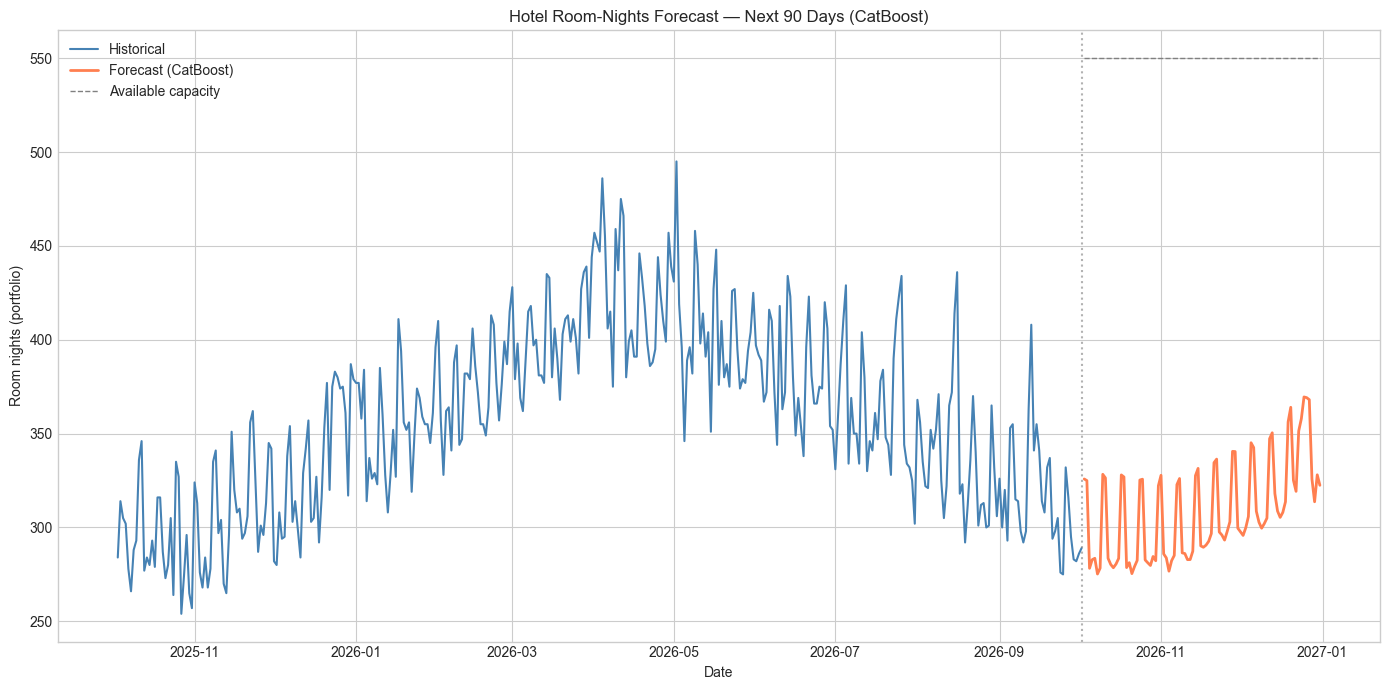

In [35]:
# Plot future forecast with capacity ceiling
fig, ax = plt.subplots(figsize=(14, 7))
hist_plot = full_history.iloc[-365:]
ax.plot(hist_plot['date'], hist_plot[TARGET_COL], label='Historical', color='steelblue', linewidth=1.5)
ax.plot(future_dates, future_preds.values, label=f'Forecast ({best_name})', color='coral', linewidth=2)
ax.plot(future_dates, future_capacity, label='Available capacity', color='gray',
        linestyle='--', linewidth=1)
if future_lo is not None:
    ax.fill_between(future_dates, future_lo, future_hi, alpha=0.2, color='coral', label='95% CI')
ax.axvline(x=last_observed, color='gray', linestyle=':', alpha=0.6)
ax.set_title(f'Hotel Room-Nights Forecast — Next {horizon} Days ({best_name})')
ax.set_xlabel('Date')
ax.set_ylabel('Room nights (portfolio)')
ax.legend()
fig.tight_layout()
plt.show()

In [36]:
# Assumptions & Limitations (honest reporting)
print("=== Supuestos ===")
assumptions = [
    "Los patrones históricos de demanda (tendencia, estacionalidad, festivos CR) continúan.",
    "Sin choques externos mayores (eventos, crisis, cambios regulatorios).",
    f"Capacidad futura = último valor observado ({last_capacity:.0f} hab/día); sin renovaciones anunciadas.",
    "La operación hotelera se mantiene consistente con los datos observados.",
]
for i, a in enumerate(assumptions, 1):
    print(f"  {i}. {a}")

print("\n=== Limitaciones ===")
limitations = [
    "Datos sintéticos: las cifras validan la metodología, no son números de negocio.",
    "La incertidumbre crece con el horizonte (90 días es exigente).",
    "Sin datos forward-looking del PMS (pickup/reservas, bloques de grupos, tarifas planeadas).",
    "Sin datos exógenos (clima, vuelos, mercados emisores, competencia).",
    "Reentrenar periódicamente con datos nuevos y monitorear el error.",
]
for i, l in enumerate(limitations, 1):
    print(f"  {i}. {l}")

=== Supuestos ===
  1. Los patrones históricos de demanda (tendencia, estacionalidad, festivos CR) continúan.
  2. Sin choques externos mayores (eventos, crisis, cambios regulatorios).
  3. Capacidad futura = último valor observado (550 hab/día); sin renovaciones anunciadas.
  4. La operación hotelera se mantiene consistente con los datos observados.

=== Limitaciones ===
  1. Datos sintéticos: las cifras validan la metodología, no son números de negocio.
  2. La incertidumbre crece con el horizonte (90 días es exigente).
  3. Sin datos forward-looking del PMS (pickup/reservas, bloques de grupos, tarifas planeadas).
  4. Sin datos exógenos (clima, vuelos, mercados emisores, competencia).
  5. Reentrenar periódicamente con datos nuevos y monitorear el error.


---
## Section 9: Conclusions

**Marco de decisión aplicado:**
1. **¿Supera el naive?** MASE < 1 es requisito mínimo.
2. **¿La ventaja es estadísticamente real?** Diebold-Mariano con Newey-West.
3. **¿Es utilizable por el negocio?** WAPE < 10% en hotelería suele bastar para planificar personal, inventario y pricing.
4. **¿Es sostenible?** Monitoreo + reentrenamiento periódico.

**Honestidad como política**: datos sintéticos declarados, TimesFM excluido en vez de fingido, advertencias junto a las cifras.

In [37]:
best_row = comparison_df.loc[best_name]
naive_row = comparison_df.loc['SeasonalNaive']
improvement = (1 - best_row['MAE'] / naive_row['MAE']) * 100

print("=" * 64)
print("     CONCLUSIONES — ROOM NIGHTS (protocolo honesto multi-paso)")
print("=" * 64)
print(f"\n1. MODELO GANADOR (MAE en test): {best_name}")
print(f"   MAE: {best_row['MAE']:.1f} room nights/día | RMSE: {best_row['RMSE']:.1f} | WAPE: {best_row['WAPE']:.1f}%")
print(f"   MASE: {best_row['MASE']:.2f}  (<1 significa que supera al seasonal naive)")
print(f"   Mejora vs SeasonalNaive (MAE): {improvement:.1f}%")
try:
    sig = dm_df[dm_df['Better & significant']]
    print(f"\n2. SIGNIFICANCIA ESTADISTICA (Diebold-Mariano, Newey-West h=7):")
    print(f"   {best_name} supera significativamente a: {list(sig.index) if len(sig) else 'ninguno (p>=0.05)'}")
except Exception:
    pass
print(f"\n3. PRONOSTICO {horizon} DIAS (mejor modelo reentrenado con TODA la historia):")
print(f"   Total: {future_preds.sum():,.0f} room nights | Media diaria: {future_preds.mean():,.1f}")
print(f"   Ocupación implícita media: {future_occ.mean():.1%} | Días recortados por capacidad: {len(cap_report)}")
print(f"\n4. ADVERTENCIAS HONESTAS:")
print("   - Datos SINTETICOS: conecte el SQL real para números de negocio.")
print("   - Métricas multi-paso reales: los reales del test jamás fueron entradas ML.")
print("   - El salto a 'precisión excelente' requiere datos forward-looking del PMS")
print("     (pickup/reservas, bloques de grupos, tarifas planeadas) — ver design.md.")
print("   - Incertidumbre crece con el horizonte; reentrenar periódicamente.")
print("=" * 64)

     CONCLUSIONES — ROOM NIGHTS (protocolo honesto multi-paso)

1. MODELO GANADOR (MAE en test): CatBoost
   MAE: 14.3 room nights/día | RMSE: 19.7 | WAPE: 4.0%
   MASE: 0.29  (<1 significa que supera al seasonal naive)
   Mejora vs SeasonalNaive (MAE): 71.3%

2. SIGNIFICANCIA ESTADISTICA (Diebold-Mariano, Newey-West h=7):
   CatBoost supera significativamente a: ['Prophet', 'PatchTST', 'SeasonalNaive', 'ETS', 'SARIMAX']

3. PRONOSTICO 90 DIAS (mejor modelo reentrenado con TODA la historia):
   Total: 27,747 room nights | Media diaria: 308.3
   Ocupación implícita media: 56.1% | Días recortados por capacidad: 0

4. ADVERTENCIAS HONESTAS:
   - Datos SINTETICOS: conecte el SQL real para números de negocio.
   - Métricas multi-paso reales: los reales del test jamás fueron entradas ML.
   - El salto a 'precisión excelente' requiere datos forward-looking del PMS
     (pickup/reservas, bloques de grupos, tarifas planeadas) — ver design.md.
   - Incertidumbre crece con el horizonte; reentrena